In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stat
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score,precision_score,f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


### Impor dataset (CSV) & cleanign dataframe 

In [2]:
df =pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.columns =df.columns.str.lower()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   hba1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


1. Column data diubah menjadi huruf kecil sehingga dapat diakses 
2. Tidak ada data yang hilang 


### EDA

In [7]:
df.describe()

,age,hypertension,heart_disease,bmi,hba1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [8]:
profile=ProfileReport (df,title='profiling Report')

profile.to_file("report_timeseries.html")
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:01<00:00,  5.74it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

##### kemungkinan kendala 
1. hubungan linier yang kuat dengan diabetes adalah hba1c dan blood_glucose_level
2. feture gender tidak memiliki hubungan linear yang kuat dengan feature yang lain.
3. Age memiliki jumlah total yang merata namun over di 80 asumsi penderita diabetes meningkat pertambahan umur. (analisis lanjut dengan mengelompokkan umur dengan penderitanya)
4. Data bmi memiliki outlier 
5. patient penderita diabetes tidak balance

### Split data
membagi dan acak dataframe  menjadi data train dan test

In [9]:
x=df[df.columns[:-1]]
y =df[df.columns[-1]]


In [10]:
x_train, x_test, y_train, y_test= train_test_split (x,y, test_size=0.25, random_state=42)
print (len(x_train))
print (len (x_test))

75000
25000


##### 1. data frame 1
1. menggunakan data mentah
2. Feature enginering dengan mengubah text menjadi number
3. standar scalling data
4. mengatasi inbalance data

In [11]:
# standar scalling max dan min data numerik
x_train.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'hba1c_level', 'blood_glucose_level'],
      dtype='object')

In [12]:
x_t1 =x_train[:]
y_t1= y_train[:]
x_ts1=x_test[:]
y_ts1=y_test[:]

In [13]:
def scal_max_min(df_,columns_:str):
    min_=df_[columns_].min()
    max_=df_[columns_].max()
    vals=[]
    for i in range (len(df_[columns_])):
        j=(df_.iloc[i][columns_])
        val=(j-min_)/(max_-min_) 
        vals.append(val)
    df_[columns_]=vals



In [14]:
cols =[ 'age', 'bmi', 'hba1c_level', 'blood_glucose_level']
def scal(columns,df_):
    for col in columns :
        scal_max_min(df_,col)


scal (cols,x_t1)
scal (cols,x_ts1)
      

In [15]:
x_t1.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level
98980,Female,0.336837,0,0,former,0.211588,0.563636,0.354545
69824,Female,0.224224,0,0,never,0.144970,0.090909,0.545455
9928,Male,0.411912,0,0,No Info,0.211588,0.272727,0.000000
75599,Female,0.624625,0,0,never,0.311453,0.490909,0.045455
95621,Male,1.000000,0,1,No Info,0.310353,0.854545,0.340909


In [16]:
x_ts1.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level
75721,Female,0.161662,0,0,No Info,0.124327,0.418182,0.209091
80184,Female,0.036537,0,0,No Info,0.126433,0.272727,0.295455
19864,Male,0.787287,0,0,former,0.176959,0.000000,0.545455
76699,Female,0.024024,0,0,never,0.084678,0.472727,0.209091
92991,Female,0.411912,0,0,not current,0.349591,0.490909,0.545455


In [17]:
# endcoding data
# 1. Gender tidak memiliki nilai atau hirearki
# 2. Memiliki nilai atau hirearki (smoking histri)

def no_val(df,col:str):
    unik=df[col].unique().tolist()
    total =len(unik)
    for i in range (total):
        df[unik[i]]=np.where (
            df[col]==unik[i],
            1,
            0
        )

def val(list_,df,columns_):
    total=len(list_)
    for l in range(1,total+1):
        i=l-1
        df[columns_]=np.where(
            df[columns_]==list_[i],
            l,
            df[columns_]
        )

In [18]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [19]:
no_val(x_ts1, 'gender')
no_val(x_t1, 'gender')
list_=['No Info' ,'never','former', 'not current' ,'ever','current']
val(list_,x_ts1,'smoking_history')
val(list_,x_t1,'smoking_history')


In [20]:
x_ts1 = x_ts1.drop(['gender'],axis =1)

In [21]:
x_t1 = x_t1.drop(['gender'],axis =1)

In [22]:
x_t1.head()

,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,Female,Male,Other
98980,0.336837,0,0,3,0.211588,0.563636,0.354545,1,0,0
69824,0.224224,0,0,2,0.144970,0.090909,0.545455,1,0,0
9928,0.411912,0,0,1,0.211588,0.272727,0.000000,0,1,0
75599,0.624625,0,0,2,0.311453,0.490909,0.045455,1,0,0
95621,1.000000,0,1,1,0.310353,0.854545,0.340909,0,1,0


#### Menjalankan model

In [23]:
model_1=LogisticRegression(class_weight='balanced')
model_1.fit(x_t1,y_t1)
y_p1 =model_1.predict (x_ts1)
f1_1= f1_score(y_p1,y_ts1)
re_1=recall_score (y_p1,y_ts1)
pres_1=precision_score(y_p1,y_ts1)

print (
    f'''
    f1={f1_1} 
    recall={re_1}
    precition={pres_1}
'''
)




    f1=0.5822903629536921 
    recall=0.4387081565299387
    precition=0.8655813953488372



In [24]:
model_2=DecisionTreeClassifier(class_weight='balanced')
model_2.fit(x_t1,y_t1)
y_p1 =model_2.predict (x_ts1)
f1_2= f1_score(y_p1,y_ts1)
re_2=recall_score (y_p1,y_ts1)
pres_2=precision_score(y_p1,y_ts1)

print (
    f'''
    f1={f1_2} 
    recall={re_2}
    precition={pres_2}
'''
)


    f1=0.7444976076555024 
    recall=0.7665024630541872
    precition=0.7237209302325581



In [25]:
model_3=KNeighborsClassifier()
model_3.fit(x_t1,y_t1)
y_p1 =model_3.predict (x_ts1)
f1_3 = f1_score(y_p1,y_ts1)
re_3=recall_score (y_p1,y_ts1)
pres_3=precision_score(y_p1,y_ts1)

print (
    f'''
    f1={f1_3} 
    recall={re_3}
    precition={pres_3}
'''
)


    f1=0.723428249224697 
    recall=0.9183965640658555
    precition=0.5967441860465116



Model lebih cocok menggunakan jenis machine learning tree 


#### 2. Dataset 2 

1. feature enginering data bmi
2. cek data bisa di binding
3. scaling data (max-min dan std methode)
4. endcoding character-> numerik


1. feature enginering

In [26]:
x_t2 =x_train[:]
y_t2 =y_train[:]
x_ts2=x_test [:]
y_ts2 =y_test[:]

In [27]:
# cek outlier
x_t2['bmi']

98980    27.32
69824    21.87
9928     27.32
75599    35.49
95621    35.40
         ...  
6265     32.98
54886    28.10
76820    26.14
860      24.96
15795    27.99
Name: bmi, Length: 75000, dtype: float64

In [28]:
%matplotlib inline
def outlier_graph (df,columns_):
    fig, ax =plt.subplots (1,3 ,figsize=(16,4))
    sns.histplot(data=df, x=columns_, ax=ax[0])
    sns.boxplot(data=df[columns_],ax=ax[1])
    stat.probplot(df[columns_],dist='norm',plot=plt)
    plt.show()

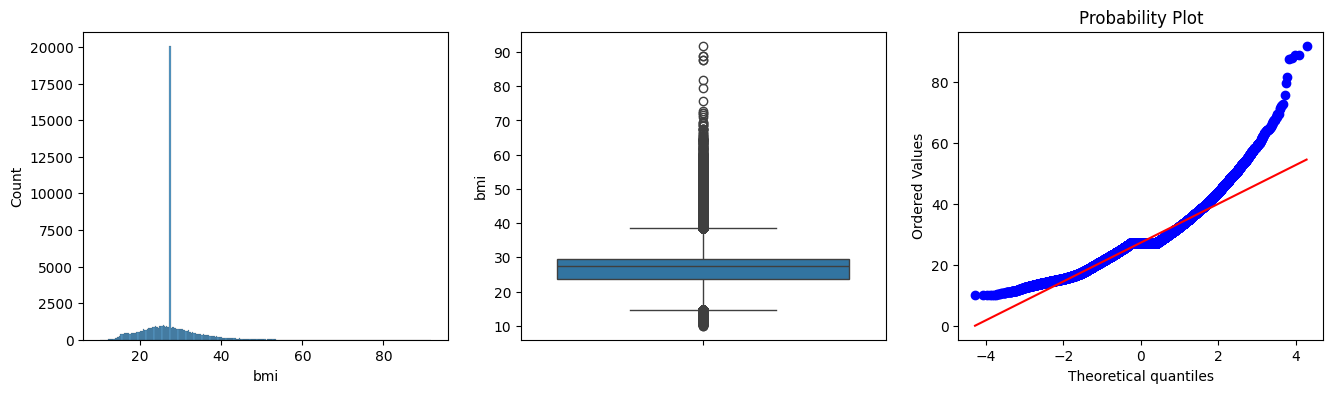

In [29]:
outlier_graph (x_t2,'bmi')

In [30]:
def outlier(df,column_):
    Q1=df[column_].quantile(0.25)
    Q3 = df[column_].quantile(0.75)
    std_=df[column_].std()
    IQR_=Q3-Q1
    atas_=Q3+IQR_*std_
    bawah_ =Q1-IQR_*std_
    return atas_,bawah_


def change(df,column_):
    up,bot =outlier  (df,column_)
    df[column_]=np.where(
        df[column_]>up,
        up,
        df[column_]
    )
    df[column_]=np.where(
        df[column_]<bot,
        bot,
        df[column_]
    )

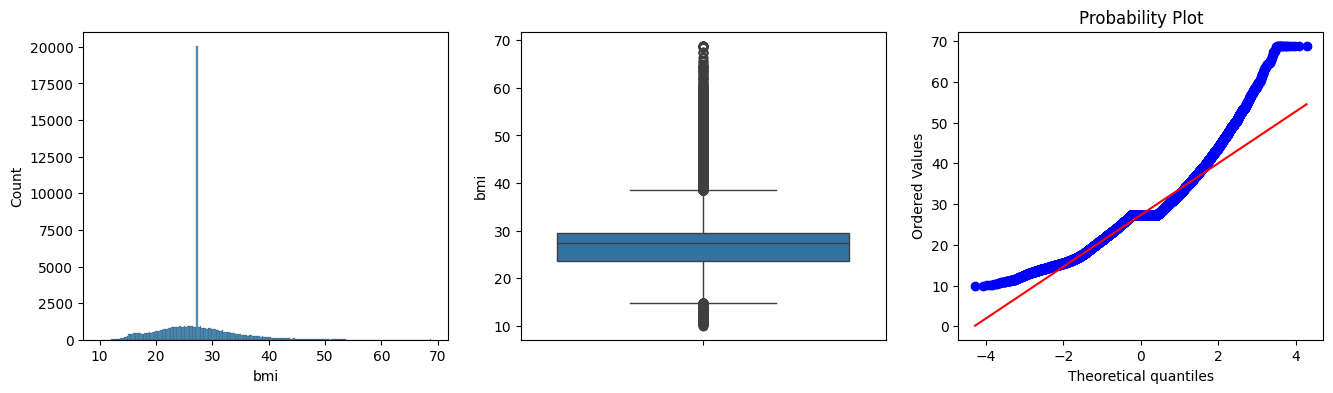

In [31]:
change(x_t2,'bmi')
outlier_graph (x_t2,'bmi')

2. standar scaling

In [32]:
cols=['age','bmi','hba1c_level','blood_glucose_level']
def max_min(df,column):
    max_ =df[column].max()
    min_=df[column].min()
    vals =[]
    for x in df[column]:
        val =(x-min_)/(max_-min_)
        vals.append (val)
    df [column]=vals

for i in cols:
    max_min(x_train,i)

3. endcoding

In [33]:
no_val(x_ts2, 'gender')
no_val(x_t2, 'gender')
list_=['No Info' ,'never','former', 'not current' ,'ever','current']
val(list_,x_ts2,'smoking_history')
val(list_,x_t2,'smoking_history')

/tmp/ipykernel_16418/1614727669.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[unik[i]]=np.where (
/tmp/ipykernel_16418/1614727669.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[unik[i]]=np.where (
/tmp/ipykernel_16418/1614727669.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

In [34]:
x_t2 = x_t2.drop(['gender'],axis =1)
x_ts2 = x_ts2.drop(['gender'],axis =1)
x_t2 = x_t2.drop(['age'],axis =1)
x_ts2 = x_ts2.drop(['age'],axis =1)

In [35]:
model_4=DecisionTreeClassifier(class_weight='balanced')
model_4.fit(x_t2,y_t2)
y_p4 =model_4.predict (x_ts2)
f1_4 = f1_score(y_p4,y_ts2)
re_4=recall_score (y_p4,y_ts2)
pres_4=precision_score(y_p4,y_ts2)

print (
    f'''
    f1={f1_4} 
    recall={re_4}
    precition={pres_4}
'''
)


    f1=0.6950543357728987 
    recall=0.6642645188639253
    precition=0.7288372093023255



In [36]:
model_5=KNeighborsClassifier()
model_5.fit(x_t2,y_t2)
y_p4_5 =model_4.predict (x_ts2)
f1_5 = f1_score(y_p4,y_ts2)
re_5=recall_score (y_p4,y_ts2)
pres_5=precision_score(y_p4,y_ts2)

print (
    f'''
    f1_5={f1_5} 
    recall_5={re_5}
    precition_5={pres_5}
'''
)


    f1_5=0.6950543357728987 
    recall_5=0.6642645188639253
    precition_5=0.7288372093023255



In [37]:
# graphic
data={
    'label':['model1','model2','model3','model4','model5'],
    'f1':[f1_1,f1_2,f1_3,f1_4,f1_5],
    'recall':[re_1,re_2,re_3,re_4,re_5],
    'precition':[pres_1,pres_2,pres_3,pres_4,pres_5]
}
hasil=pd.DataFrame(data)

In [38]:
hasil.head()

,label,f1,recall,precition
0,model1,0.582290,0.438708,0.865581
1,model2,0.744498,0.766502,0.723721
2,model3,0.723428,0.918397,0.596744
3,model4,0.695054,0.664265,0.728837
4,model5,0.695054,0.664265,0.728837


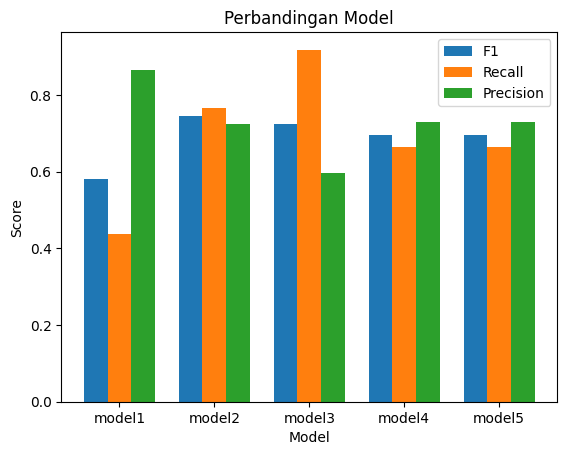

In [39]:
%matplotlib inline

x = np.arange(len(hasil['label']))
width = 0.25

plt.bar(x - width, hasil['f1'], width, label='F1')
plt.bar(x, hasil['recall'], width, label='Recall')
plt.bar(x + width, hasil['precition'], width, label='Precision')

plt.xticks(x, hasil['label'])
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Perbandingan Model")
plt.legend()

plt.show()

kesimpulan:
1. 3 model yang digunkan KKN,desicionTree dan logistic regretion. Model logistic regretion memiliki model yang lebih kuat dalam memprediksi diabetes(model 2)
2. Model melakukan featuering enginering dengan mengganti otlier dan model menghasilkan nilai yang menurun.
3. bining data tidak efektif diterapkan pada train data 
4. data sangat berkembang dengan model apa yang dipakai
5. Data yang disedia cukup  discaling dan enbeding data untuk dijalankan di model machine learning